In [4]:
import pandas as pd
import numpy as np

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [5]:
import pandas as pd
print(pd.__version__)

3.0.0


In [6]:
train_path = "../data/KDDTrain+.txt"
test_path = "../data/KDDTest+.txt"

print("Paths created successfully!")

Paths created successfully!


In [7]:
columns = [
    'duration','protocol_type','service','flag','src_bytes',
    'dst_bytes','land','wrong_fragment','urgent','hot',
    'num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root',
    'num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login',
    'count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate',
    'diff_srv_rate','srv_diff_host_rate','dst_host_count',
    'dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','difficulty'
]

print("Total Columns:", len(columns))

Total Columns: 43


In [8]:
train_df = pd.read_csv(
    train_path,
    names=columns
)

test_df = pd.read_csv(
    test_path,
    names=columns
)

print("Training Shape:", train_df.shape)
print("Testing Shape:", test_df.shape)

Training Shape: (125973, 43)
Testing Shape: (22544, 43)


In [9]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,attack,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [10]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  str    
 2   service                      125973 non-null  str    
 3   flag                         125973 non-null  str    
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              125973 non-null  int64  
 13  root_shell

In [11]:
train_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
count,125973.00000,1.259730e+05,1.259730e+05,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,...,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000,125973.000000
mean,287.14465,4.556674e+04,1.977911e+04,0.000198,0.022687,0.000111,0.204409,0.001222,0.395736,0.279250,...,115.653005,0.521242,0.082951,0.148379,0.032542,0.284452,0.278485,0.118832,0.120240,19.504060
std,2604.51531,5.870331e+06,4.021269e+06,0.014086,0.253530,0.014366,2.149968,0.045239,0.489010,23.942042,...,110.702741,0.448949,0.188922,0.308997,0.112564,0.444784,0.445669,0.306557,0.319459,2.291503
min,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.00000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
50%,0.00000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,63.000000,0.510000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000
75%,0.00000,2.760000e+02,5.160000e+02,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000,21.000000
max,42908.00000,1.379964e+09,1.309937e+09,1.000000,3.000000,3.000000,77.000000,5.000000,1.000000,7479.000000,...,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,21.000000


In [12]:
train_df['attack'].value_counts()

attack
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

In [13]:
print("Number of attack classes:")
print(train_df['attack'].nunique())

Number of attack classes:
23


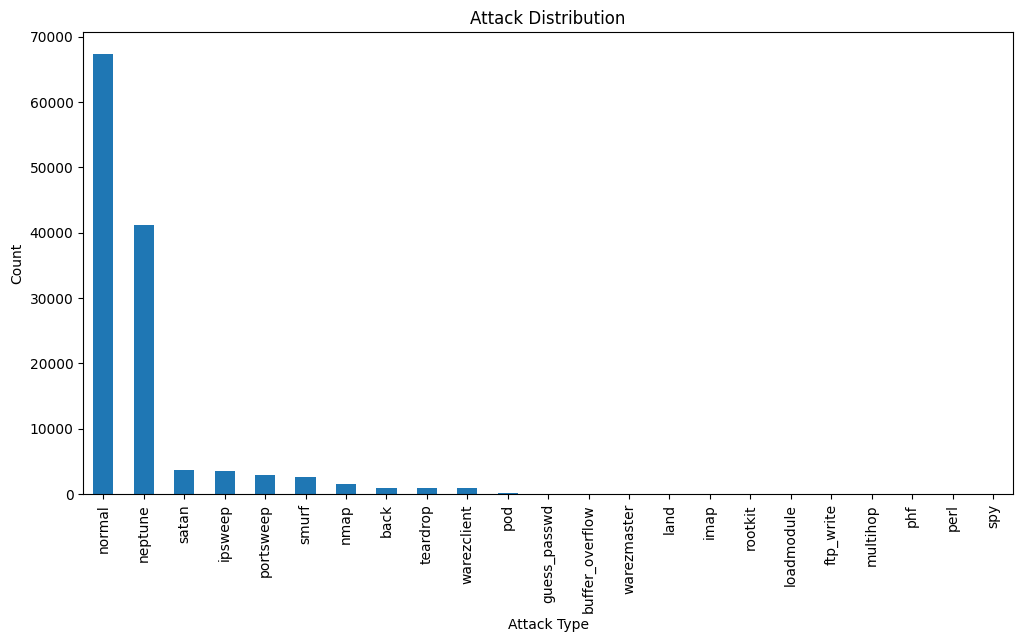

In [14]:
import matplotlib.pyplot as plt

attack_counts = train_df['attack'].value_counts()

plt.figure(figsize=(12,6))
attack_counts.plot(kind='bar')

plt.title('Attack Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Count')

plt.show()

In [15]:
attack_mapping = {

    # Normal
    'normal': 'Normal',

    # DoS
    'back': 'DoS',
    'land': 'DoS',
    'neptune': 'DoS',
    'pod': 'DoS',
    'smurf': 'DoS',
    'teardrop': 'DoS',

    # Probe
    'ipsweep': 'Probe',
    'nmap': 'Probe',
    'portsweep': 'Probe',
    'satan': 'Probe',

    # R2L
    'ftp_write': 'R2L',
    'guess_passwd': 'R2L',
    'imap': 'R2L',
    'multihop': 'R2L',
    'phf': 'R2L',
    'spy': 'R2L',
    'warezclient': 'R2L',
    'warezmaster': 'R2L',

    # U2R
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'rootkit': 'U2R'
}

print("Mapping Created Successfully")

Mapping Created Successfully


In [16]:
train_df['attack_class'] = train_df['attack'].map(attack_mapping)

test_df['attack_class'] = test_df['attack'].map(attack_mapping)

print("Attack categories created!")

Attack categories created!


In [17]:
train_df['attack_class'].value_counts()

attack_class
Normal    67343
DoS       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64

In [18]:
categorical_cols = ['protocol_type', 'service', 'flag']

for col in categorical_cols:
    print(f"\n{col}")
    print(train_df[col].nunique())


protocol_type
3

service
70

flag
11


In [19]:
for col in categorical_cols:
    print(f"\n{col}")
    print(train_df[col].unique()[:10])


protocol_type
<ArrowStringArray>
['tcp', 'udp', 'icmp']
Length: 3, dtype: str

service
<ArrowStringArray>
[  'ftp_data',      'other',    'private',       'http', 'remote_job',
       'name', 'netbios_ns',      'eco_i',        'mtp',     'telnet']
Length: 10, dtype: str

flag
<ArrowStringArray>
['SF', 'S0', 'REJ', 'RSTR', 'SH', 'RSTO', 'S1', 'RSTOS0', 'S3', 'S2']
Length: 10, dtype: str


In [20]:
X_train = train_df.drop(
    columns=['attack', 'attack_class']
)

y_train = train_df['attack_class']

X_test = test_df.drop(
    columns=['attack', 'attack_class']
)

y_test = test_df['attack_class']

print(X_train.shape)
print(y_train.shape)

(125973, 42)
(125973,)


In [21]:
categorical_cols = [
    'protocol_type',
    'service',
    'flag'
]

print(categorical_cols)

['protocol_type', 'service', 'flag']


In [22]:
X_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,20
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21


In [23]:
print('protocol_type' in X_train.columns)
print('service' in X_train.columns)
print('flag' in X_train.columns)

True
True
True


In [24]:
X_train.shape

(125973, 42)

In [25]:
X_train.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,20
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,21


In [26]:
print(test_df['attack_class'].isna().sum())

3750


In [27]:
test_df[test_df['attack_class'].isna()]['attack'].value_counts()

attack
mscan            996
apache2          737
processtable     685
snmpguess        331
saint            319
mailbomb         293
snmpgetattack    178
httptunnel       133
named             17
ps                15
sendmail          14
xterm             13
xlock              9
xsnoop             4
worm               2
sqlattack          2
udpstorm           2
Name: count, dtype: int64

In [28]:
print(train_df['attack_class'].isna().sum())

0


In [29]:
attack_mapping.update({

    # Probe
    'mscan': 'Probe',
    'saint': 'Probe',

    # DoS
    'apache2': 'DoS',
    'mailbomb': 'DoS',
    'processtable': 'DoS',
    'udpstorm': 'DoS',

    # R2L
    'ftp_write': 'R2L',
    'named': 'R2L',
    'sendmail': 'R2L',
    'snmpgetattack': 'R2L',
    'snmpguess': 'R2L',
    'worm': 'R2L',
    'xlock': 'R2L',
    'xsnoop': 'R2L',
    'httptunnel': 'R2L',

    # U2R
    'buffer_overflow': 'U2R',
    'loadmodule': 'U2R',
    'perl': 'U2R',
    'rootkit': 'U2R',
    'ps': 'U2R',
    'sqlattack': 'U2R',
    'xterm': 'U2R'
})

In [30]:
train_df['attack_class'] = train_df['attack'].map(attack_mapping)
test_df['attack_class'] = test_df['attack'].map(attack_mapping)

In [31]:
print("Train NaN:", train_df['attack_class'].isna().sum())
print("Test NaN:", test_df['attack_class'].isna().sum())

Train NaN: 0
Test NaN: 0


In [32]:
print("Train NaN:", train_df['attack_class'].isna().sum())
print("Test NaN:", test_df['attack_class'].isna().sum())

Train NaN: 0
Test NaN: 0


In [33]:
test_df[test_df['attack_class'].isna()]['attack'].value_counts()

Series([], Name: count, dtype: int64)

In [34]:
y_train = train_df['attack_class']
y_test = test_df['attack_class']

In [35]:
print(y_train.isna().sum())
print(y_test.isna().sum())

0
0


In [36]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Classes:", label_encoder.classes_)

Classes: ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train_encoded)

print("Random Forest trained successfully!")

ValueError: could not convert string to float: 'tcp'

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (125973, 123)
X_test : (22544, 117)


In [ ]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (125973, 123)
X_test : (22544, 123)


In [ ]:
y_pred = rf_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.758694109297374


In [ ]:
print("Accuracy:", accuracy)

Accuracy: 0.758694109297374


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         DoS       0.96      0.80      0.88      7458
      Normal       0.66      0.97      0.79      9711
       Probe       0.83      0.64      0.72      2421
         R2L       0.90      0.03      0.06      2887
         U2R       0.67      0.39      0.49        67

    accuracy                           0.76     22544
   macro avg       0.80      0.57      0.59     22544
weighted avg       0.81      0.76      0.71     22544



In [ ]:
print(X_train.dtypes.value_counts())

int64      24
float64    15
str         3
Name: count, dtype: int64


In [ ]:
categorical_cols = ['protocol_type', 'service', 'flag']

In [ ]:
X_train = pd.get_dummies(
    X_train,
    columns=categorical_cols
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_cols
)

In [ ]:
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(125973, 123)
(22544, 123)


In [ ]:
X_train.select_dtypes(include=['object']).columns

Index([], dtype='str')

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train_encoded)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [ ]:
y_pred = rf_model.predict(X_test)

print("Predictions completed!")

Predictions completed!


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.758694109297374


In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_encoded,
        y_pred,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

         DoS       0.96      0.80      0.88      7458
      Normal       0.66      0.97      0.79      9711
       Probe       0.83      0.64      0.72      2421
         R2L       0.90      0.03      0.06      2887
         U2R       0.67      0.39      0.49        67

    accuracy                           0.76     22544
   macro avg       0.80      0.57      0.59     22544
weighted avg       0.81      0.76      0.71     22544



In [ ]:
import pickle

with open('../models/random_forest.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('../models/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

print("Model saved successfully!")

Model saved successfully!


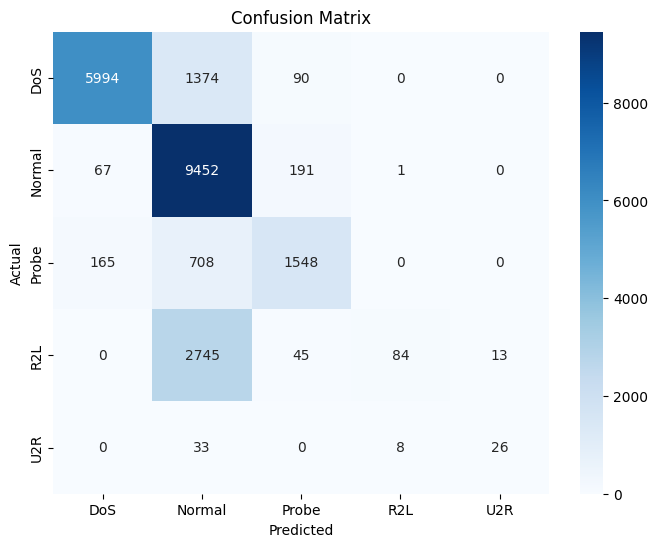

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_encoded, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,src_bytes,0.116691
25,same_srv_rate,0.091051
2,dst_bytes,0.070246
19,count,0.052913
26,diff_srv_rate,0.052369
121,flag_SF,0.046821
30,dst_host_same_srv_rate,0.046810
117,flag_S0,0.042281
38,difficulty,0.039326
35,dst_host_srv_serror_rate,0.038828


<Figure size 1200x600 with 0 Axes>

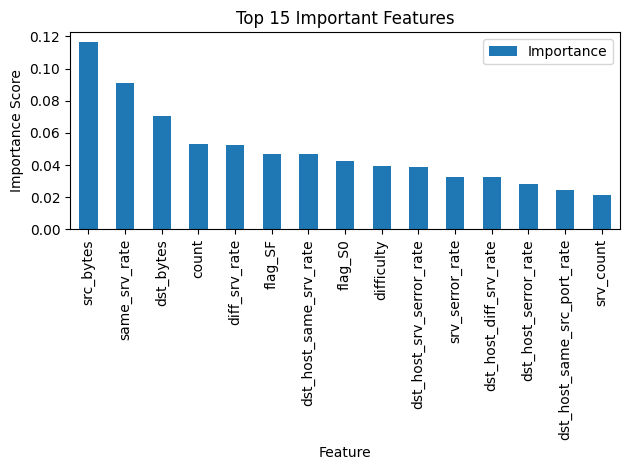

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

feature_importance.head(15).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.title("Top 15 Important Features")
plt.ylabel("Importance Score")
plt.tight_layout()

plt.show()

In [ ]:
print(X_train.columns.tolist())

['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'difficulty', 'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_domain_u', 'serv

In [ ]:
import pickle

with open("../models/feature_columns.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)

print("Feature columns saved successfully!")

Feature columns saved successfully!


In [ ]:
[x for x in globals().keys() if not x.startswith("_")]

['In', 'Out', 'get_ipython', 'exit', 'quit', 'open']

In [38]:
print(X_train.select_dtypes(include=['object']).columns)

Index(['protocol_type', 'service', 'flag'], dtype='str')


C:\Users\Rushik Pujari\AppData\Local\Temp\ipykernel_9412\1115170628.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(X_train.select_dtypes(include=['object']).columns)


In [39]:
[X for X in globals().keys() if "encoded" in X.lower()]

['y_train_encoded', 'y_test_encoded']

In [40]:
X_train = pd.get_dummies(
    X_train,
    columns=['protocol_type', 'service', 'flag']
)

X_test = pd.get_dummies(
    X_test,
    columns=['protocol_type', 'service', 'flag']
)

X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

print("Encoding completed!")
print(X_train.shape)
print(X_test.shape)

Encoding completed!
(125973, 123)
(22544, 123)


In [41]:
print(X_train.select_dtypes(include=['object']).columns)

Index([], dtype='str')


In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train_encoded)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [43]:
y_pred = rf_model.predict(X_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test_encoded, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.758694109297374


In [44]:
import pandas as pd

print(pd.Series(y_train_encoded).value_counts())

1    67343
0    45927
2    11656
3      995
4       52
Name: count, dtype: int64


In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(X_train, y_train_encoded)

print("Balanced Random Forest trained!")

Balanced Random Forest trained!


In [46]:
y_pred_balanced = rf_balanced.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:",
      accuracy_score(y_test_encoded,
                     y_pred_balanced))

print(
    classification_report(
        y_test_encoded,
        y_pred_balanced,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.7525727466288148
              precision    recall  f1-score   support

         DoS       0.96      0.80      0.87      7458
      Normal       0.65      0.97      0.78      9711
       Probe       0.87      0.62      0.73      2421
         R2L       0.68      0.00      0.01      2887
         U2R       0.71      0.18      0.29        67

    accuracy                           0.75     22544
   macro avg       0.77      0.52      0.53     22544
weighted avg       0.78      0.75      0.70     22544



In [47]:
from sklearn.ensemble import RandomForestClassifier

rf_model2 = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model2.fit(X_train, y_train_encoded)

print("Improved Random Forest trained!")

Improved Random Forest trained!


In [48]:
y_pred2 = rf_model2.predict(X_test)

from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:",
      accuracy_score(y_test_encoded,
                     y_pred2))

print(
    classification_report(
        y_test_encoded,
        y_pred2,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.7451206529453513
              precision    recall  f1-score   support

         DoS       0.96      0.77      0.86      7458
      Normal       0.64      0.97      0.77      9711
       Probe       0.86      0.62      0.72      2421
         R2L       0.95      0.02      0.04      2887
         U2R       0.73      0.16      0.27        67

    accuracy                           0.75     22544
   macro avg       0.83      0.51      0.53     22544
weighted avg       0.81      0.75      0.70     22544



In [49]:
print(X_train.shape)
print(X_test.shape)

(125973, 123)
(22544, 123)


In [50]:
print(X_train.columns.tolist())

['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'difficulty', 'protocol_type_icmp', 'protocol_type_tcp', 'protocol_type_udp', 'service_IRC', 'service_X11', 'service_Z39_50', 'service_aol', 'service_auth', 'service_bgp', 'service_courier', 'service_csnet_ns', 'service_ctf', 'service_daytime', 'service_discard', 'service_domain', 'service_domain_u', 'serv

In [51]:
for i, cls in enumerate(label_encoder.classes_):
    print(i, "->", cls)

0 -> DoS
1 -> Normal
2 -> Probe
3 -> R2L
4 -> U2R


In [52]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test_encoded, y_pred)

print(cm)

[[5994 1374   90    0    0]
 [  67 9452  191    1    0]
 [ 165  708 1548    0    0]
 [   0 2745   45   84   13]
 [   0   33    0    8   26]]


In [53]:
import pandas as pd

pd.Series(y_test_encoded).value_counts()

1    9711
0    7458
3    2887
2    2421
4      67
Name: count, dtype: int64

In [54]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb.fit(X_train, y_train_encoded)

y_pred_xgb = xgb.predict(X_test)

In [55]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_encoded,
    y_pred_xgb,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

         DoS       0.96      0.83      0.89      7458
      Normal       0.72      0.97      0.83      9711
       Probe       0.72      0.68      0.70      2421
         R2L       0.98      0.24      0.39      2887
         U2R       0.46      0.54      0.49        67

    accuracy                           0.80     22544
   macro avg       0.77      0.65      0.66     22544
weighted avg       0.83      0.80      0.78     22544



In [56]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(20))

                         Feature  Importance
25                 same_srv_rate    0.332384
18                is_guest_login    0.248581
57                 service_ecr_i    0.104098
1                      src_bytes    0.034451
66                  service_http    0.029783
10                    root_shell    0.028998
26                 diff_srv_rate    0.025930
7              num_failed_logins    0.024467
9                num_compromised    0.020562
56                 service_eco_i    0.017715
4                 wrong_fragment    0.016785
115                  flag_RSTOS0    0.016687
31        dst_host_diff_srv_rate    0.014871
38                    difficulty    0.013026
62              service_ftp_data    0.008364
34          dst_host_serror_rate    0.007503
32   dst_host_same_src_port_rate    0.005380
30        dst_host_same_srv_rate    0.003952
117                      flag_S0    0.003448
8                      logged_in    0.003259


In [57]:
print("difficulty" in X_train.columns)

True


In [58]:
X_train2 = X_train.drop("difficulty", axis=1)
X_test2 = X_test.drop("difficulty", axis=1)

print(X_train2.shape)
print(X_test2.shape)

(125973, 122)
(22544, 122)


In [59]:
from xgboost import XGBClassifier

xgb2 = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb2.fit(X_train2, y_train_encoded)

print("XGBoost retrained without difficulty!")

XGBoost retrained without difficulty!


In [60]:
from sklearn.metrics import accuracy_score, classification_report

y_pred2 = xgb2.predict(X_test2)

print("Accuracy:", accuracy_score(y_test_encoded, y_pred2))

print(
    classification_report(
        y_test_encoded,
        y_pred2,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.7776792051100071
              precision    recall  f1-score   support

         DoS       0.96      0.84      0.90      7458
      Normal       0.68      0.97      0.80      9711
       Probe       0.80      0.67      0.73      2421
         R2L       0.98      0.07      0.12      2887
         U2R       0.67      0.12      0.20        67

    accuracy                           0.78     22544
   macro avg       0.82      0.53      0.55     22544
weighted avg       0.83      0.78      0.74     22544



In [61]:
top20_features = feature_importance.head(20)["Feature"].tolist()

print(top20_features)

['same_srv_rate', 'is_guest_login', 'service_ecr_i', 'src_bytes', 'service_http', 'root_shell', 'diff_srv_rate', 'num_failed_logins', 'num_compromised', 'service_eco_i', 'wrong_fragment', 'flag_RSTOS0', 'dst_host_diff_srv_rate', 'difficulty', 'service_ftp_data', 'dst_host_serror_rate', 'dst_host_same_src_port_rate', 'dst_host_same_srv_rate', 'flag_S0', 'logged_in']


In [62]:
top20_features = feature_importance.head(20)["Feature"].tolist()

for i, f in enumerate(top20_features, 1):
    print(i, f)

1 same_srv_rate
2 is_guest_login
3 service_ecr_i
4 src_bytes
5 service_http
6 root_shell
7 diff_srv_rate
8 num_failed_logins
9 num_compromised
10 service_eco_i
11 wrong_fragment
12 flag_RSTOS0
13 dst_host_diff_srv_rate
14 difficulty
15 service_ftp_data
16 dst_host_serror_rate
17 dst_host_same_src_port_rate
18 dst_host_same_srv_rate
19 flag_S0
20 logged_in


In [63]:
X_train_top20 = X_train[top20_features]
X_test_top20 = X_test[top20_features]

print(X_train_top20.shape)
print(X_test_top20.shape)

(125973, 20)
(22544, 20)


In [64]:
from xgboost import XGBClassifier

xgb_top20 = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

xgb_top20.fit(X_train_top20, y_train_encoded)

print("Top20 model trained!")

Top20 model trained!


In [65]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_top20 = xgb_top20.predict(X_test_top20)

print("Accuracy:", accuracy_score(y_test_encoded, y_pred_top20))

print(
    classification_report(
        y_test_encoded,
        y_pred_top20,
        target_names=label_encoder.classes_
    )
)

Accuracy: 0.7702714691270405
              precision    recall  f1-score   support

         DoS       0.96      0.81      0.88      7458
      Normal       0.69      0.97      0.81      9711
       Probe       0.77      0.63      0.70      2421
         R2L       0.94      0.12      0.21      2887
         U2R       0.13      0.40      0.19        67

    accuracy                           0.77     22544
   macro avg       0.70      0.59      0.56     22544
weighted avg       0.82      0.77      0.74     22544



In [66]:
from xgboost import XGBClassifier

final_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss"
)

final_model.fit(X_train, y_train_encoded)

print("Final model trained!")

Final model trained!


In [67]:
import joblib

joblib.dump(final_model, "xgboost_ids.pkl")

print("Model saved!")

Model saved!


In [68]:
joblib.dump(label_encoder, "label_encoder_xgb.pkl")

print("Encoder saved!")

Encoder saved!


In [69]:
joblib.dump(X_train.columns.tolist(), "feature_columns_xgb.pkl")

print("Features saved!")

Features saved!


In [2]:
import os

print(os.getcwd())

d:\Intrusion-Detection-System\notebooks


In [3]:
import os

print(os.listdir())

['eda.ipynb']


In [4]:
import joblib

model = joblib.load("../models/xgboost_ids.pkl")
print(type(model))

<class 'xgboost.sklearn.XGBClassifier'>


In [5]:
encoder = joblib.load("../models/label_encoder_xgb.pkl")
print(type(encoder))

<class 'sklearn.preprocessing._label.LabelEncoder'>


In [6]:
features = joblib.load("../models/feature_columns_xgb.pkl")

print(type(features))
print(len(features))

<class 'list'>
123


In [8]:
import pandas as pd
import joblib

xgb = joblib.load("../models/xgboost_ids.pkl")

feature_columns = joblib.load(
    "../models/feature_columns_xgb.pkl"
)

feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("Feature Importance Saved!")

Feature Importance Saved!


In [9]:
pd.read_csv("../reports/feature_importance.csv").head()

,Feature,Importance
0,same_srv_rate,0.332384
1,is_guest_login,0.248581
2,service_ecr_i,0.104098
3,src_bytes,0.034451
4,service_http,0.029783


In [11]:
print("y_test_encoded" in globals())
print("y_pred" in globals())

False
False


In [13]:
print("X_test" in globals())

False
